In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame

import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [2]:
import os
np.set_printoptions(legacy='1.25')
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
atom1, atom2 = 'Rb', 'Cs'
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')
energy_unit = 'GHz'
preferQuantumDefects = True


js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]

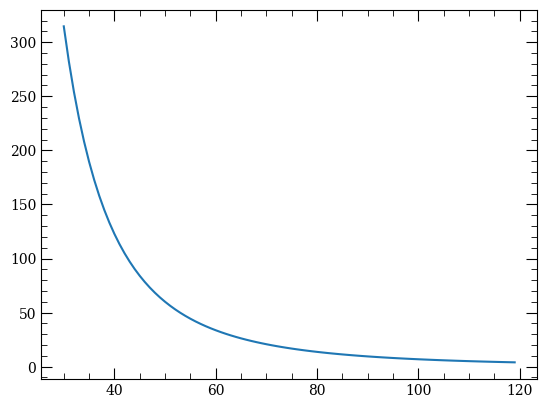

In [3]:
def defect_import(atom1, atom2, l1, l2, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif):
    path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'

    data = pd.read_csv(path)
    ns, defects = data['n'], data['defect']
    return ns.to_numpy(), defects.to_numpy()

n1 = 65
n2 = 74
n1_1, n2_1 = 66, 72

l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1

j1_0, j2_0 = 1/2, 1/2
j1_1, j2_1 = 1/2, 1/2

change1 = 0
change2 = 0
dif = 0

ns, defect = defect_import(atom1, atom2, l1_0, l2_0, j1_0, j2_0, l1_1, l2_1, j1_1, j2_1, change1, change2, dif)
plt.figure()
plt.plot (ns, defect)
plt.show() 

In [ ]:
difs = np.arange(-8,9)
changes = np.arange(-3, 4)
l1, l2 = 0, 0
atom1, atom2 = 'Cs', 'Cs'
min_n = 30
max_n = 120
num=1
w=1

ls=[0]
for l in ls:
    for j1 in js[l]:
        for j2 in js[l]:
            for l1_1 in (l-1, l+1):
                if l1_1 < 0:
                    continue
                for l2_1 in (l-1, l+1):
                    if l2_1 < 0:
                        continue  
                    df = {'n1_0' : [], 'l1_0' : [], 'j1_0' : [],
                        'n2_0' : [], 'l2_0' : [], 'j2_0' : [],
                        'n1_1' : [], 'l1_1' : [], 'j1_1' : [],
                        'n2_1' : [], 'l2_1' : [], 'j2_1' : [],
                        'dif' : [], 'change1' : [], 'change2' : [],
                        'defect' : [], 'c3k' : []}                  
                    
                    for dif in difs:
                        for change1 in changes:
                            
                            for change2 in changes:
                                jpdelta = []
                                labels = []
                                
                                for j1_1 in js[l1_1]:
                                    if abs(j1_1 - j1) > 1:
                                        continue

                                    for j2_1 in js[l2_1]: 
                                        if abs(j2_1 - j2) > 1:
                                            continue

                                        ns, defect = defect_import(atom1, atom2, l, l, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif)
                                        defect = list(defect)
                                        min_defect = min(np.array(defect), key=abs)

                                        for i in [-1,0,1]:

                                            try:
                                                assoc_n = ns[defect.index(min_defect) + i]
                                                delta = defect[defect.index(min_defect) + i]
                                                n1, n2 = assoc_n, assoc_n+dif
                                                n1_1, n2_1 = assoc_n+change1, assoc_n + change2 + dif
                                                ket1 = pi.KetAtom(atom1, n=assoc_n, l=l, j=j1, m=j1, s=1/2)
                                                ket2 = pi.KetAtom(atom2, n=assoc_n+dif, l=l, j=j2, m=j2, s=1/2)
                                                ket1_1 = pi.KetAtom(atom1, n=assoc_n+change1, l=l1_1, j=j1_1, m=j1_1, s=1/2)
                                                ket2_1 = pi.KetAtom(atom2, n=assoc_n+dif+change2, l=l2_1, j=j2_1, m=j2_1, s=1/2)
                                                            
                                            except  IndexError:
                                                continue


                                            if atom1 == 'Rb':
                                                rb_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n1, l, j1, n1_1, l1_1, j1_1)     
                                            else:
                                                rb_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n1, l, j1, n1_1, l1_1, j1_1)
                                            if atom2 == 'Rb':
                                                cs_matrix_element_j = arc.Rubidium().getReducedMatrixElementJ(n2, l, j2, n2_1, l2_1, j2_1)     
                                            else:
                                                cs_matrix_element_j = arc.Caesium().getReducedMatrixElementJ(n2, l, j2, n2_1, l2_1, j2_1)

                                            c3k = (a_0[0]*e) **2 / h / (4*np.pi*epsilon_0) * 1e9 * cs_matrix_element_j * rb_matrix_element_j/np.sqrt(2*j1_1+1)/np.sqrt(2*j2_1+1)

                                            level_spacing = pi.KetAtom(atom1, n=assoc_n, l=l, j=j1, m=1/2).get_energy(unit = energy_unit) - pi.KetAtom(atom1, n=assoc_n+1, l=l, j=j1, m=1/2).get_energy(unit = energy_unit)

                                            if abs(delta) < 0.0005 * abs(level_spacing) and abs(c3k) > 1 and 40 < assoc_n < 90:

                                                print(num)
                                                num+=1
                                                print(f'channel = {ket1}, {ket2} -> {ket1_1}, {ket2_1}')
                                                # print(f'channel {jps.index(jp)+1} = |Rb {c['n1_0']}s_1/2, Rb {c['n2_0']}s_1/2> -> |Rb {c['n1_1']}p_{c['j1_1']}, Rb {c['n2_1']}p_{c['j2_1']}>')
                                                print(f'min defect = {delta*1e3} MHz')
                                                print(f'c3k = {c3k}')
                                        
                                                df['n1_0'].append(n1)
                                                df['l1_0'].append(l)
                                                df['j1_0'].append(j1)
                                                df['n2_0'].append(n2)
                                                df['l2_0'].append(l)
                                                df['j2_0'].append(j2)
                                                df['n1_1'].append(n1_1)
                                                df['l1_1'].append(l1_1)
                                                df['j1_1'].append(j1_1)
                                                df['n2_1'].append(n2_1)
                                                df['l2_1'].append(l2_1)
                                                df['j2_1'].append(j2_1)
                                                df['dif'].append(dif)
                                                df['change1'].append(change1)
                                                df['change2'].append(change2)
                                                df['defect'].append(delta*1e3)
                                                df['c3k'].append(c3k)
                        print(f'ls: {int(list(ls).index(l)/len(ls)*100)}% | j1s: {int(list(js[l]).index(j1)/len(js[l])*100)}% | j2s: {int(list(js[l]).index(j2)/len(js[l])*100)}% | l1_1, l2_1: {l1_1},{l2_1} | difs: {int(list(difs).index(dif)/len(difs)*100)}%')



                    channelData_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}\\{orbs[l]}{orbs[l]}\\j1j2({j1},{j2})\\'
                    import os
                    if not os.path.exists(channelData_path):
                        os.makedirs(channelData_path)
                    df = pd.DataFrame(df)
                    df.sort_values(by='n1_0', ascending=True).to_csv(channelData_path + f'\\to {orbs[l1_1]}{orbs[l2_1]}.csv', index=False)


ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 0%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 5%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 11%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 17%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 23%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 29%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 35%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 41%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 47%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 52%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 58%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 64%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 70%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 76%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 82%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 88%
ls: 0% | j1s: 0% | j2s: 0% | l1_1, l2_1: 1,1 | difs: 94%
ls: 0% | j1s: 0% | j2s: 0% | l1_1

In [4]:
channelData_path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}.csv'

df.sort_values(by='n1_0', ascending=True).to_csv(channelData_path + f'\\to {orbs[l1_1]}{orbs[l2_1]}.csv', index=False)
df.to_csv(channelData_path, index=False)
print(df.sort_values(by='n1_0', ignore_index=False))

NameError: name 'df' is not defined

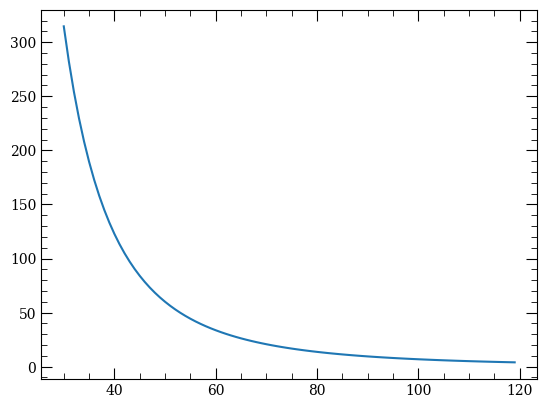

In [5]:
def defect_import(atom1, atom2, l1, l2, j1, j2, l1_1, l2_1, j1_1, j2_1, change1, change2, dif):
    path = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\data\\defects\\{atom1}{atom2}\\{orbs[l1]}{orbs[l2]}\\j1j2({j1},{j2})\\to {orbs[l1_1]}{orbs[l2_1]}\\{j1_1}, {j2_1} {dif} {change1} {change2}.csv'

    data = pd.read_csv(path)
    ns, defects = data['n'], data['defect']
    return ns.to_numpy(), defects.to_numpy()
atom1, atom2 = 'Rb', 'Rb'
n1 = 65
n2 = 74
n1_1, n2_1 = 66, 72

l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1

j1_0, j2_0 = 1/2, 1/2
j1_1, j2_1 = 1/2, 1/2

change1 = 0
change2 = 0
dif = 0

ns, defect = defect_import(atom1, atom2, l1_0, l2_0, j1_0, j2_0, l1_1, l2_1, j1_1, j2_1, change1, change2, dif)
plt.figure()
plt.plot (ns, defect)
plt.show() 

In [9]:
import pandas as pd
atom1, atom2 = 'Rb', 'Cs'
ls=[0]
js = [[1/2], [1/2, 3/2], [3/2, 5/2], [5/2, 7/2]]
asym_r=3
for l in ls:
    l1_0 = l
    l2_0=l
    for j1_0 in js[l]:
        for j2_0 in js[l]:
            for l1_1 in (l-1, l+1):
                if l1_1 < 0:
                    continue
                for l2_1 in (l-1, l+1):
                    if l2_1 < 0:
                        continue  

                    c = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)
                    # c = pd.read_csv(fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}.csv')
                    fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\channels\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}.csv'
                    # \\{orbs[l1_0]}{orbs[l2_0]}\\j1j2({j1_0},{j2_0})\\to {orbs[l1_1]}{orbs[l2_1]}
                    asym_r = 10
                    # print(c)
                    # latexed = {'Target' : [fr'${c['n1_0'][i]}{orbs[l1_0]}_{{{int(2*j1_0)}/2}}$ ${c['n2_0'][i]}{orbs[l2_0]}_{{{int(2*j2_0)}/2}}$' for i in range(len(c))], 'Resonant' : [fr'${c['n1_1'][i]}{orbs[l1_1]}_{{{int(2*c['j1_1'][i])}/2}}$ ${c['n2_1'][i]}{orbs[c['l2_1'][i]]}_{{{int(2*c['j2_1'][i])}/2}}$' for i in range(len(c))], 'defect' : [round(c['defect'][i],2) for i in range(len(c))], 'c3k' : [round(c['c3k'][i],2) for i in range(len(c))]}

                    latexed = {'Target' : [fr'${c['n1_0'][i]}{orbs[l1_0]}_{{{int(2*j1_0)}/2}}$ ${c['n2_0'][i]}{orbs[l2_0]}_{{{int(2*j2_0)}/2}}$' for i in range(len(c))], 'Resonant' : [fr'${c['n1_1'][i]}{orbs[l1_1]}_{{{int(2*c['j1_1'][i])}/2}}$ ${c['n2_1'][i]}{orbs[c['l2_1'][i]]}_{{{int(2*c['j2_1'][i])}/2}}$' for i in range(len(c))], 'defect' : [round(c['defect'][i],2) for i in range(len(c))], 'c3k' : [round(c['c3k'][i],2) for i in range(len(c))], 'E (MHz)' : [round(c[f'energy {asym_r}um'][i],2) for i in range(len(c))], '$\zeta$' : [round(c[f'asymmetry {asym_r}um'][i],2) for i in range(len(c))], 'Rb-Rb Energy (MHz)' : [round(c[f'energy_Rb {asym_r}um'][i],2) for i in range(len(c))], 'Cs-Cs Energy (MHz)' : [round(c[f'energy_Cs {asym_r}um'][i],2) for i in range(len(c))]}
                    print(pd.DataFrame(latexed).to_latex(
                                    float_format="{:.2f}".format))

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  ...  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46  ...   
1     46     0   0.5    48     0   0.5    46     1   1.5    47  ...   
2     48     0   0.5    51     0   0.5    48     1   1.5    50  ...   
3     59     0   0.5    57     0   0.5    58     1   0.5    57  ...   
4     61     0   0.5    65     0   0.5    61     1   0.5    64  ...   
5     68     0   0.5    67     0   0.5    67     1   0.5    67  ...   
6     69     0   0.5    68     0   0.5    68     1   0.5    68  ...   
7     71     0   0.5    69     0   0.5    70     1   1.5    69  ...   
8     72     0   0.5    70     0   0.5    71     1   1.5    70  ...   
9     72     0   0.5    75     0   0.5    72     1   0.5    74  ...   
10    73     0   0.5    76     0   0.5    73     1   0.5    75  ...   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  ...   
12    81     0   0.5    78     0   0.5    80     1   0.5    78  ...   
13    

<>:26: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? A raw string is also an option.
<>:26: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? A raw string is also an option.
C:\Users\Tommy\AppData\Local\Temp\ipykernel_5812\1797530322.py:26: SyntaxWarning: "\z" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\z"? A raw string is also an option.
  latexed = {'Target' : [fr'${c['n1_0'][i]}{orbs[l1_0]}_{{{int(2*j1_0)}/2}}$ ${c['n2_0'][i]}{orbs[l2_0]}_{{{int(2*j2_0)}/2}}$' for i in range(len(c))], 'Resonant' : [fr'${c['n1_1'][i]}{orbs[l1_1]}_{{{int(2*c['j1_1'][i])}/2}}$ ${c['n2_1'][i]}{orbs[c['l2_1'][i]]}_{{{int(2*c['j2_1'][i])}/2}}$' for i in range(len(c))], 'defect' : [round(c['defect'][i],2) for i in range(len(c))], 'c3k' : [round(c['c3k'][i],2) for i in range(len(c))], 'E (MHz)' : [round(c[f'energy {asym_r}um'][i]